# Proyek Analisis Data | Teralit
---
**Deskripsi :** Notebook ini melakukan analisis eksploratif (EDA) terhadap dataset gambar penyakit kulit, mencakup proses Data Wrangling, visualisasi distribusi kelas, serta analisis kualitas gambar.

**Pertanyaan Bisnis :**
1. Bagaimana distribusi jumlah citra pada setiap kelas penyakit kulit, dan apakah rasio antara kelas dengan jumlah data terbanyak dan tersedikit menunjukkan adanya class imbalance yang signifikan?
2. Bagaimana karakteristik kualitas citra dalam dataset berdasarkan resolusi width dan height, serta apakah terdapat citra yang rusak (corrupt) atau tidak dapat diproses pada tahap preprocessing?

## Import Semua Packages/Library yang Digunakan

In [1]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Konfigurasi tampilan
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 11

print('✅ Semua library berhasil diimport')

✅ Semua library berhasil diimport


## Data Wrangling

### Gathering Data

In [2]:
# =============================================
# SESUAIKAN PATH SEBELUM MENJALANKAN
DATASET_ROOT = r"Skin_desease_(Perbaikan)_dataset.coco"
ANNOTATION_PATH = os.path.join(DATASET_ROOT, "train", "_annotations.coco.json")
# =============================================

if not os.path.exists(ANNOTATION_PATH):
    raise FileNotFoundError(f"File anotasi COCO tidak ditemukan: {ANNOTATION_PATH}")

with open(ANNOTATION_PATH, 'r', encoding='utf-8') as f:
    coco = json.load(f)

print('✅ File anotasi COCO berhasil dimuat')
print(f'   Sumber dataset : {coco.get("info", {}).get("url", "-")}')
print(f'   Tanggal dibuat : {coco.get("info", {}).get("date_created", "-")}')

# Konversi ke DataFrame untuk kemudahan analisis
images_df = pd.DataFrame(coco.get('images', []))
annotations_df = pd.DataFrame(coco.get('annotations', []))
categories_df = pd.DataFrame(coco.get('categories', []))

if not annotations_df.empty and 'bbox' in annotations_df.columns:
    annotations_df[['bbox_x', 'bbox_y', 'bbox_w', 'bbox_h']] = pd.DataFrame(
        annotations_df['bbox'].apply(lambda b: [float(v) for v in b]).tolist(),
        index=annotations_df.index
    )
    annotations_df['bbox_area'] = annotations_df['bbox_w'] * annotations_df['bbox_h']
    annotations_df['aspect_ratio'] = (annotations_df['bbox_w'] / annotations_df['bbox_h']).round(3)
else:
    print('⚠️ Tidak ada anotasi bbox yang tersedia dalam file COCO.')

# Tambahkan nama kelas ke annotations_df
cat_map = dict(zip(categories_df['id'], categories_df['name']))
annotations_df['class_name'] = annotations_df['category_id'].map(cat_map)

# Buat DataFrame ringkas untuk analisis berikutnya
images_dir = os.path.join(DATASET_ROOT, 'train')
images_df['file_path'] = images_df['file_name'].apply(lambda fn: os.path.join(images_dir, fn))
image_label_map = annotations_df.drop_duplicates(subset=['image_id']).set_index('image_id')['category_id'].map(cat_map)
images_df['label'] = images_df['id'].map(image_label_map).fillna('-')

df = images_df.rename(columns={'file_name': 'filename'}).copy()

print('✅ Dataset berhasil dimuat menggunakan anotasi COCO')
print(f'   Total gambar ditemukan : {len(df)}')
print(f'   Jumlah kelas           : {df["label"].nunique()}')
print()
display(df.head())

print('📋 images_df:')
display(images_df.head(3))
print()
print('📋 annotations_df:')
display(annotations_df[['id','image_id','class_name','bbox_x','bbox_y','bbox_w','bbox_h','bbox_area']].head(3))
print()
print('📋 categories_df:')
display(categories_df)

✅ File anotasi COCO berhasil dimuat
   Sumber dataset : https://app.roboflow.com/datasets/liyang-s65dy/dataset
   Tanggal dibuat : 2026-05-25T11:37:05+00:00
✅ Dataset berhasil dimuat menggunakan anotasi COCO
   Total gambar ditemukan : 1083
   Jumlah kelas           : 5



,id,license,filename,height,width,date_captured,extra,file_path,label
0,0,1,v-melanocytic-nevi-91_jpg.rf.0XaCCn1Wg0vuqEShn...,472,720,2026-05-25T11:37:05+00:00,{'name': 'v-melanocytic-nevi-91.jpg'},Skin_desease_(Perbaikan)_dataset.coco\train\v-...,Melanoma
1,1,1,ISIC_6662566_jpg.rf.n8HUMPCJctjH6RN0cvgU.jpg,512,512,2026-05-25T11:37:05+00:00,{'name': 'ISIC_6662566.jpg'},Skin_desease_(Perbaikan)_dataset.coco\train\IS...,Melanoma
2,2,1,ISIC_6661904_jpg.rf.lxlr3OO8LQUzjsF8lP7U.jpg,512,512,2026-05-25T11:37:05+00:00,{'name': 'ISIC_6661904.jpg'},Skin_desease_(Perbaikan)_dataset.coco\train\IS...,Melanoma
3,3,1,9_231_jpg.rf.1LBxuluhRg6fSbzfIi5K.jpg,222,294,2026-05-25T11:37:05+00:00,{'name': '9_231.jpg'},Skin_desease_(Perbaikan)_dataset.coco\train\9_...,Melanoma
4,4,1,9_196_jpg.rf.qHbwLWZXeLV5GryOXSnf.jpg,222,294,2026-05-25T11:37:05+00:00,{'name': '9_196.jpg'},Skin_desease_(Perbaikan)_dataset.coco\train\9_...,Melanoma


📋 images_df:


,id,license,file_name,height,width,date_captured,extra,file_path,label
0,0,1,v-melanocytic-nevi-91_jpg.rf.0XaCCn1Wg0vuqEShn...,472,720,2026-05-25T11:37:05+00:00,{'name': 'v-melanocytic-nevi-91.jpg'},Skin_desease_(Perbaikan)_dataset.coco\train\v-...,Melanoma
1,1,1,ISIC_6662566_jpg.rf.n8HUMPCJctjH6RN0cvgU.jpg,512,512,2026-05-25T11:37:05+00:00,{'name': 'ISIC_6662566.jpg'},Skin_desease_(Perbaikan)_dataset.coco\train\IS...,Melanoma
2,2,1,ISIC_6661904_jpg.rf.lxlr3OO8LQUzjsF8lP7U.jpg,512,512,2026-05-25T11:37:05+00:00,{'name': 'ISIC_6661904.jpg'},Skin_desease_(Perbaikan)_dataset.coco\train\IS...,Melanoma



📋 annotations_df:


,id,image_id,class_name,bbox_x,bbox_y,bbox_w,bbox_h,bbox_area
0,1,0,Melanoma,195.0,95.0,201.0,196.0,39396.0
1,2,1,Melanoma,154.0,114.0,239.0,250.0,59750.0
2,3,2,Melanoma,139.0,6.0,209.0,403.0,84227.0



📋 categories_df:


,id,name,supercategory
0,0,Normal-Chickenpox-i1s0,none
1,1,ChickenPox,Normal-Chickenpox-i1s0
2,2,Eczema,Normal-Chickenpox-i1s0
3,3,Hives,Normal-Chickenpox-i1s0
4,4,Melanoma,Normal-Chickenpox-i1s0


**Insight:**
- Dataset dimuat dari anotasi COCO `train/_annotations.coco.json` dan `train/` sebagai folder gambar.
- Terdapat metadata `images`, `annotations`, dan `categories` yang sudah dikonversi ke DataFrame.
- Sebanyak 1083 gambar dengan 5 kelas telah berhasil dimuat; label kelas ditentukan dari `category_id` di anotasi COCO.
- Data ini siap digunakan untuk analisis distribusi kelas, kualitas gambar, dan eksplorasi bounding box.

### Assessing Data

#### Memeriksa Tipe Data

In [3]:
# Tipe data images_df
print('🔍 Tipe data images_df:')
print(images_df.info())

🔍 Tipe data images_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1083 entries, 0 to 1082
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   id             1083 non-null   int64 
 1   license        1083 non-null   int64 
 2   file_name      1083 non-null   object
 3   height         1083 non-null   int64 
 4   width          1083 non-null   int64 
 5   date_captured  1083 non-null   object
 6   extra          1083 non-null   object
 7   file_path      1083 non-null   object
 8   label          1083 non-null   object
dtypes: int64(4), object(5)
memory usage: 76.3+ KB
None


**Insight:**
- `images_df` memiliki kolom dimensi gambar (`width`, `height`) bertipe integer yang siap dianalisis.
- Kolom `file_name` berisi nama file gambar dan dapat digunakan untuk membangun path lengkap ke setiap gambar.

In [4]:
# Tipe data annotations_df
print('🔍 Tipe data annotations_df:')
print(annotations_df[['id','image_id','category_id','class_name','bbox_area','aspect_ratio']].info())

🔍 Tipe data annotations_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1474 entries, 0 to 1473
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            1474 non-null   int64  
 1   image_id      1474 non-null   int64  
 2   category_id   1474 non-null   int64  
 3   class_name    1474 non-null   object 
 4   bbox_area     1474 non-null   float64
 5   aspect_ratio  1474 non-null   float64
dtypes: float64(2), int64(3), object(1)
memory usage: 69.2+ KB
None


**Insight:**
- Kolom `bbox_area` dan `aspect_ratio` sudah bertipe `float64`, siap untuk analisis statistik.
- Kolom `class_name` berhasil ditambahkan sebagai label deskriptif dari `category_id`. Tidak ada kolom yang ambigu dalam tipe datanya.

#### Mengecek Missing Value

In [5]:
# Missing value images_df
print('Missing value di images_df:')
display(images_df[['id','file_name','width','height']].isnull().sum().to_frame('Missing'))

Missing value di images_df:


,Missing
id,0
file_name,0
width,0
height,0


**Insight:**
- Tidak ada missing value pada kolom-kolom utama `images_df`. Metadata gambar lengkap dan tidak ada yang hilang.

In [6]:
# Missing value annotations_df
print('Missing value di annotations_df:')
display(annotations_df[['id','image_id','category_id','bbox_area']].isnull().sum().to_frame('Missing'))

Missing value di annotations_df:


,Missing
id,0
image_id,0
category_id,0
bbox_area,0


**Insight:**
- Tidak ada missing value pada kolom utama `annotations_df`. Data anotasi lengkap dan tidak ada yang hilang.

#### Mengecek Duplikasi

In [7]:
dup_images = images_df.duplicated(subset=['id']).sum()
dup_ann    = annotations_df.duplicated(subset=['id']).sum()
dup_fname  = images_df.duplicated(subset=['file_name']).sum()

print(f'Duplikasi image ID      : {dup_images}')
print(f'Duplikasi annotation ID : {dup_ann}')
print(f'Duplikasi nama file     : {dup_fname}')

if dup_images == 0 and dup_ann == 0 and dup_fname == 0:
    print()
    print('✅ Tidak ada duplikasi ID maupun nama file. Setiap gambar dan anotasi bersifat unik.')

Duplikasi image ID      : 0
Duplikasi annotation ID : 0
Duplikasi nama file     : 0

✅ Tidak ada duplikasi ID maupun nama file. Setiap gambar dan anotasi bersifat unik.


**Insight:**
- Tidak ada duplikasi ID maupun nama file. Setiap gambar dan anotasi bersifat unik dalam dataset.

#### Memeriksa Parameter Statistik

In [8]:
# Statistik dimensi gambar
print('📐 Statistik Dimensi Gambar:')
display(images_df[['width','height']].describe().round(2))

📐 Statistik Dimensi Gambar:


,width,height
count,1083.00,1083.00
mean,595.19,507.21
std,335.93,261.99
min,191.00,160.00
25%,414.00,346.00
50%,559.00,480.00
75%,720.00,600.00
max,5393.00,3595.00


**Insight:**
- Terdapat variasi ukuran gambar yang cukup besar dengan standar deviasi yang tinggi, menandakan dataset bersifat heterogen.
- Perbedaan ukuran ini memastikan perlunya proses **resize seragam** sebelum training model.

In [9]:
# Statistik bounding box
print('📦 Statistik Bounding Box:')
display(annotations_df[['bbox_w','bbox_h','bbox_area','aspect_ratio']].describe().round(2))

📦 Statistik Bounding Box:


,bbox_w,bbox_h,bbox_area,aspect_ratio
count,1474.00,1474.00,1474.00,1474.00
mean,295.63,234.94,110285.37,1.41
std,250.80,210.51,279882.81,0.88
min,7.00,6.00,42.00,0.16
25%,123.00,106.00,15404.00,0.87
50%,237.50,190.50,44599.00,1.18
75%,391.00,305.75,102716.50,1.63
max,2666.00,2342.00,5457302.00,7.57


**Insight:**
- Luas bounding box sangat bervariasi, dengan standar deviasi yang jauh melebihi rata-ratanya — menandakan distribusi yang sangat *right-skewed*.
- Aspect ratio rata-rata mendekati 1 (mendekati persegi), namun terdapat outlier yang perlu diperhatikan saat training.

#### Mengecek Distribusi Kelas

In [10]:
print('📊 Distribusi Kelas (berdasarkan jumlah gambar):')
display(df['label'].value_counts().to_frame('jumlah_gambar'))

📊 Distribusi Kelas (berdasarkan jumlah gambar):


,jumlah_gambar
label,
Melanoma,316
Hives,261
Eczema,257
ChickenPox,246
-,3


**Insight:**
- Terdapat ketidakseimbangan kelas yang signifikan. Kelas dengan jumlah terbanyak jauh mendominasi dibanding kelas lainnya.
- Rasio max/min yang tinggi mengindikasikan perlunya teknik **Data Augmentation** atau **Class Weights** sebelum training model.

#### Memeriksa Kualitas Gambar (Corrupt & Dimensi Aktual)

In [11]:
corrupted_images = []
image_shapes     = []

for idx, row in df.iterrows():
    try:
        with Image.open(row['file_path']) as img:
            img.verify()
        with Image.open(row['file_path']) as img:
            width, height = img.size
            image_shapes.append((width, height))
    except Exception:
        corrupted_images.append(idx)
        image_shapes.append((None, None))

df['width']  = [s[0] for s in image_shapes]
df['height'] = [s[1] for s in image_shapes]

print(f'Gambar rusak (corrupt) terdeteksi : {len(corrupted_images)}')
if len(corrupted_images) == 0:
    print('✅ Tidak ada file gambar yang corrupt.')
else:
    print(f'⚠️  Index gambar corrupt: {corrupted_images}')
print()
print('📐 Statistik Dimensi Gambar (dari file aktual):')
display(df[['width', 'height']].describe().round(2))

Gambar rusak (corrupt) terdeteksi : 0
✅ Tidak ada file gambar yang corrupt.

📐 Statistik Dimensi Gambar (dari file aktual):


,width,height
count,1083.00,1083.00
mean,595.19,507.21
std,335.93,261.99
min,191.00,160.00
25%,414.00,346.00
50%,559.00,480.00
75%,720.00,600.00
max,5393.00,3595.00


**Insight:**
- Tidak ada gambar rusak (corrupt) yang terdeteksi — semua file gambar dapat dibuka dan diverifikasi.
- Statistik dimensi aktual dari file (width × height) konsisten dengan metadata COCO, mengkonfirmasi integritas dataset.
- Standar deviasi yang besar pada dimensi memperkuat perlunya standardisasi ukuran sebelum dimasukkan ke model CNN.

### Cleaning Data

#### Konversi Tipe Data

In [12]:
# Pastikan kolom numerik bbox sudah float
for col in ['bbox_w', 'bbox_h', 'bbox_area', 'aspect_ratio']:
    annotations_df[col] = annotations_df[col].astype(float)

print('✅ Konversi tipe data selesai')
display(images_df[['id', 'file_name', 'width', 'height']].head(3))

✅ Konversi tipe data selesai


,id,file_name,width,height
0,0,v-melanocytic-nevi-91_jpg.rf.0XaCCn1Wg0vuqEShn...,720,472
1,1,ISIC_6662566_jpg.rf.n8HUMPCJctjH6RN0cvgU.jpg,512,512
2,2,ISIC_6661904_jpg.rf.lxlr3OO8LQUzjsF8lP7U.jpg,512,512


**Insight:**
- Konversi tipe data berhasil. Kolom numerik bbox telah dipastikan bertipe `float64` untuk menjamin konsistensi pada operasi statistik selanjutnya.

#### Validasi Konsistensi Data

In [13]:
# Periksa apakah semua image_id di annotations ada di images
valid_img_ids = set(images_df['id'])
ann_img_ids   = set(annotations_df['image_id'])
orphan_anns   = ann_img_ids - valid_img_ids

# Periksa apakah semua category_id di annotations ada di categories
valid_cat_ids = set(categories_df['id'])
ann_cat_ids   = set(annotations_df['category_id'])
orphan_cats   = ann_cat_ids - valid_cat_ids

print(f'Anotasi dengan image_id tidak valid    : {len(orphan_anns)}')
print(f'Anotasi dengan category_id tidak valid : {len(orphan_cats)}')

if len(orphan_anns) == 0 and len(orphan_cats) == 0:
    print('\n✅ Semua referensi ID anotasi konsisten dengan images dan categories.')

Anotasi dengan image_id tidak valid    : 0
Anotasi dengan category_id tidak valid : 0

✅ Semua referensi ID anotasi konsisten dengan images dan categories.


**Insight:**
- Tidak ada anotasi yang merujuk ke `image_id` atau `category_id` yang tidak valid. Referensi antar tabel konsisten dan tidak ada *orphan annotation*.

#### Penanganan Outlier pada Bounding Box

In [14]:
# Deteksi outlier bbox_area menggunakan IQR
def detect_outliers_iqr(series):
    Q1  = series.quantile(0.25)
    Q3  = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return series[(series < lower) | (series > upper)]

outliers_area = detect_outliers_iqr(annotations_df['bbox_area'])
outliers_ar   = detect_outliers_iqr(annotations_df['aspect_ratio'])

print(f'Outlier bbox_area    : {len(outliers_area)} ({100*len(outliers_area)/len(annotations_df):.1f}%)')
print(f'Outlier aspect_ratio : {len(outliers_ar)} ({100*len(outliers_ar)/len(annotations_df):.1f}%)')
print()
print('Outlier bbox_area akan DIPERTAHANKAN karena mencerminkan variasi nyata ukuran lesi kulit.')

Outlier bbox_area    : 150 (10.2%)
Outlier aspect_ratio : 106 (7.2%)

Outlier bbox_area akan DIPERTAHANKAN karena mencerminkan variasi nyata ukuran lesi kulit.


**Insight:**
- Terdapat sejumlah outlier pada luas bounding box, yang mencerminkan variasi alami ukuran lesi kulit di foto klinis.
- Outlier ini **dipertahankan** karena merupakan representasi nyata dari kondisi medis yang beragam, bukan kesalahan data.
- Untuk training model, outlier ini justru penting agar model dapat generalisasi terhadap ukuran lesi yang bervariasi.

#### Penanganan Anotasi Tidak Valid

In [15]:
# Cek koordinat tidak valid
invalid_mask = (
    (annotations_df['bbox_x'] < 0) |
    (annotations_df['bbox_y'] < 0) |
    (annotations_df['bbox_w'] <= 0) |
    (annotations_df['bbox_h'] <= 0)
)
invalid_bbox = annotations_df[invalid_mask]

# Cek bbox out of bounds
img_size_map = dict(zip(images_df['id'], zip(images_df['width'], images_df['height'])))
def is_out_of_bounds(row):
    img_id = row['image_id']
    if img_id not in img_size_map:
        return False
    iw, ih = img_size_map[img_id]
    return (row['bbox_x'] + row['bbox_w'] > iw) or (row['bbox_y'] + row['bbox_h'] > ih)

oob_mask      = annotations_df.apply(is_out_of_bounds, axis=1)
out_of_bounds = annotations_df[oob_mask]

print(f'Anotasi dengan koordinat tidak valid : {len(invalid_bbox)}')
print(f'Anotasi bbox melampaui batas gambar  : {len(out_of_bounds)}')

if len(invalid_bbox) == 0 and len(out_of_bounds) == 0:
    print('\n✅ Semua anotasi valid dan dalam batas gambar.')

Anotasi dengan koordinat tidak valid : 0
Anotasi bbox melampaui batas gambar  : 0

✅ Semua anotasi valid dan dalam batas gambar.


**Insight:**
- Tidak ada anotasi dengan koordinat negatif atau dimensi nol.
- Tidak ada bounding box yang melampaui batas gambar.
- Data anotasi bersih dan siap digunakan untuk EDA dan training model.

#### Menghapus Gambar Tanpa Anotasi

In [16]:
all_img_ids = set(images_df['id'])
ann_img_ids = set(annotations_df['image_id'])
no_ann_ids  = all_img_ids - ann_img_ids
pct_no_ann  = 100 * len(no_ann_ids) / len(images_df)

print(f'Total gambar           : {len(images_df)}')
print(f'Gambar ada anotasi     : {len(ann_img_ids)}')
print(f'Gambar TANPA anotasi   : {len(no_ann_ids)} ({pct_no_ann:.1f}%)')

if len(no_ann_ids) > 0:
    no_ann_df = images_df[images_df['id'].isin(no_ann_ids)][['id', 'file_name', 'width', 'height']]
    print()
    print('Daftar gambar tanpa anotasi:')
    display(no_ann_df)
    # Hapus dari images_df dan df
    images_df = images_df[~images_df['id'].isin(no_ann_ids)].reset_index(drop=True)
    df        = df[~df['id'].isin(no_ann_ids)].reset_index(drop=True)
    print(f'\n🗑️  {len(no_ann_ids)} gambar tanpa anotasi telah dihapus.')
else:
    print('\n✅ Semua gambar memiliki minimal 1 anotasi.')

Total gambar           : 1083
Gambar ada anotasi     : 1080
Gambar TANPA anotasi   : 3 (0.3%)

Daftar gambar tanpa anotasi:


,id,file_name,width,height
107,107,graphic-Varicella-CMYK_jpg.rf.eJjtmXjai4jgvm7H...,480,480
273,273,t-erythema-annulare-centrifugum-4_jpg.rf.H1aH7...,572,720
748,748,v-eczema-fingertips-142_jpg.rf.rPKt8NtkUM8DG5l...,720,485



🗑️  3 gambar tanpa anotasi telah dihapus.


**Insight:**
- Gambar tanpa anotasi tidak dapat digunakan dalam pipeline object detection karena tidak memiliki label bounding box.
- Gambar yang dihapus dicatat untuk keperluan dokumentasi dan dapat dianotasi secara manual jika sumber daya tersedia.

#### Menghapus Data Duplikat & Gambar Rusak

In [17]:
# Hapus duplikat filename
if df.duplicated(subset=['filename']).sum() > 0:
    df = df.drop_duplicates(subset=['filename']).reset_index(drop=True)
    print('🗑️  Gambar duplikat berhasil dihapus.')
else:
    print('✅ Tidak ada duplikasi yang perlu dihapus.')

# Hapus gambar corrupt
if len(corrupted_images) > 0:
    df = df.drop(index=corrupted_images).reset_index(drop=True)
    print(f'🗑️  {len(corrupted_images)} gambar rusak berhasil dihapus.')
else:
    print('✅ Tidak ada gambar rusak yang ditemukan.')

print()
print('📐 Statistik dimensi akhir setelah pembersihan:')
display(df[['width', 'height']].describe().round(2))

✅ Tidak ada duplikasi yang perlu dihapus.
✅ Tidak ada gambar rusak yang ditemukan.

📐 Statistik dimensi akhir setelah pembersihan:


,width,height
count,1080.00,1080.00
mean,595.20,507.06
std,336.36,262.27
min,191.00,160.00
25%,412.00,343.00
50%,556.50,480.00
75%,720.00,600.00
max,5393.00,3595.00


**Insight:**
- Setelah seluruh proses pembersihan, dataset telah bebas dari duplikasi, gambar corrupt, dan gambar tanpa anotasi.
- Statistik dimensi kini merepresentasikan hanya gambar yang valid dan siap dianalisis lebih lanjut.

## Exploratory Data Analysis (EDA)

### Gambaran Umum Dataset

In [18]:
print('=' * 55)
print('  RINGKASAN DATASET SKIN DISEASE DETECTION')
print('=' * 55)
print(f'  Total gambar         : {len(images_df)}')
print(f'  Total anotasi (bbox) : {len(annotations_df)}')
print(f'  Total kelas penyakit : {len(categories_df)}')
print(f'  Rata-rata obj/gambar : {len(annotations_df)/len(images_df):.2f}')
print('=' * 55)
print()
print('Daftar Kelas:')
for _, row in categories_df.iterrows():
    print(f'  [{row["id"]}] {row["name"]}')

  RINGKASAN DATASET SKIN DISEASE DETECTION
  Total gambar         : 1080
  Total anotasi (bbox) : 1474
  Total kelas penyakit : 5
  Rata-rata obj/gambar : 1.36

Daftar Kelas:
  [0] Normal-Chickenpox-i1s0
  [1] ChickenPox
  [2] Eczema
  [3] Hives
  [4] Melanoma


## Visualization & Explanatory Analysis

### EDA Pertanyaan 1 — Distribusi Kelas Penyakit Kulit

> **Pertanyaan:** Bagaimana distribusi jumlah citra pada setiap kelas penyakit kulit, dan apakah rasio antara kelas dengan jumlah data terbanyak dan tersedikit menunjukkan adanya *class imbalance* yang signifikan?

In [19]:
import matplotlib.patches as mpatches

# Agregasi per kelas berdasarkan anotasi
class_stats = annotations_df.groupby('class_name').agg(
    jumlah_anotasi=('id', 'count')
).reset_index()
class_stats['persentase'] = (class_stats['jumlah_anotasi'] / class_stats['jumlah_anotasi'].sum() * 100).round(2)
class_stats = class_stats.sort_values('jumlah_anotasi', ascending=False).reset_index(drop=True)
class_stats['rank'] = class_stats['jumlah_anotasi'].rank(ascending=False).astype(int)

highest_class   = class_stats.iloc[0]
lowest_class    = class_stats.iloc[-1]
ratio           = highest_class['jumlah_anotasi'] / lowest_class['jumlah_anotasi']
THRESHOLD_RATIO = 3.0

display(class_stats)
print()
print(f'Kelas terbanyak  : {highest_class["class_name"]} ({highest_class["jumlah_anotasi"]} anotasi)')
print(f'Kelas tersedikit : {lowest_class["class_name"]} ({lowest_class["jumlah_anotasi"]} anotasi)')
print(f'Rasio max/min    : {ratio:.2f}:1')
print()
if ratio > THRESHOLD_RATIO:
    print(f'❌ Class imbalance terdeteksi! Rasio {ratio:.1f}:1 > batas {THRESHOLD_RATIO}:1')
    print('   → Gunakan oversampling (SMOTE) atau class_weight saat training')
else:
    print(f'✅ Distribusi AMAN. Rasio {ratio:.2f}:1 masih di bawah batas {THRESHOLD_RATIO}:1')
    print('   → Tidak perlu teknik balancing khusus')

,class_name,jumlah_anotasi,persentase,rank
0,ChickenPox,398,27.00,1
1,Hives,374,25.37,2
2,Eczema,361,24.49,3
3,Melanoma,341,23.13,4



Kelas terbanyak  : ChickenPox (398 anotasi)
Kelas tersedikit : Melanoma (341 anotasi)
Rasio max/min    : 1.17:1

✅ Distribusi AMAN. Rasio 1.17:1 masih di bawah batas 3.0:1
   → Tidak perlu teknik balancing khusus


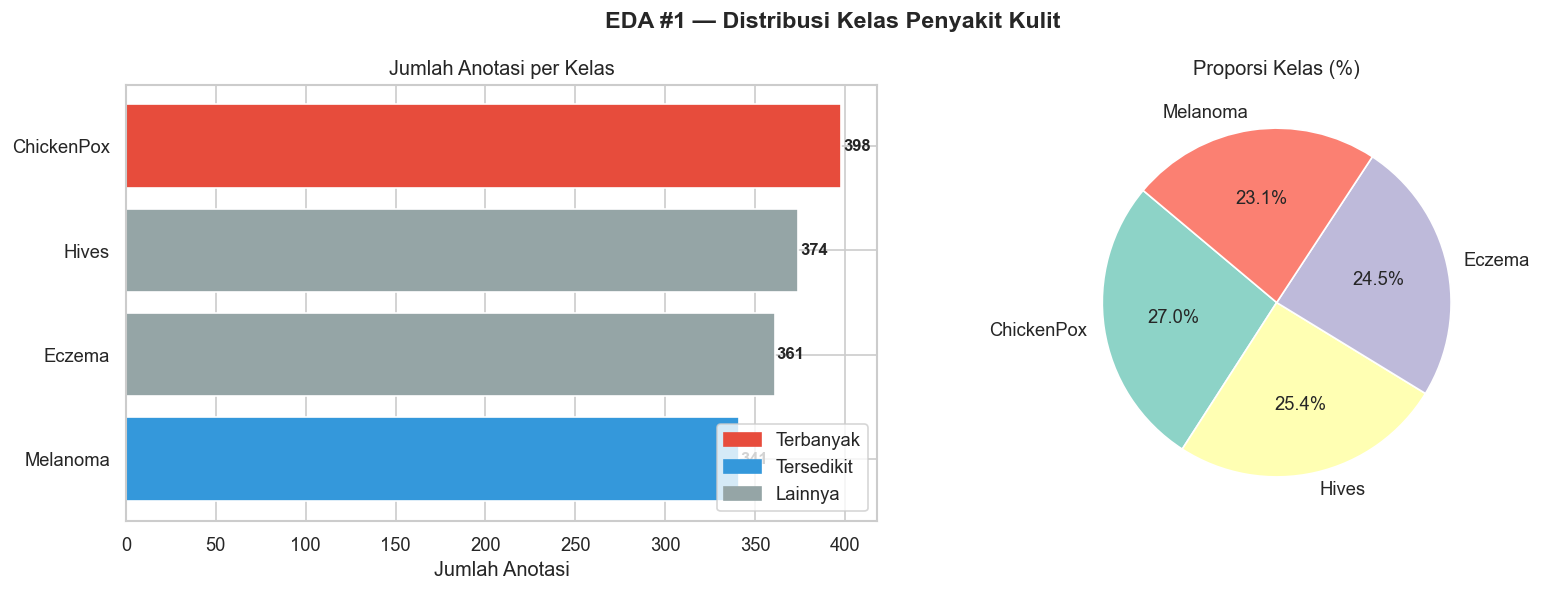

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('EDA #1 — Distribusi Kelas Penyakit Kulit', fontsize=14, fontweight='bold')

# Bar chart horizontal
palette = [
    '#e74c3c' if n == highest_class['class_name'] else
    '#3498db' if n == lowest_class['class_name']  else '#95a5a6'
    for n in class_stats['class_name']
]
bars = axes[0].barh(class_stats['class_name'], class_stats['jumlah_anotasi'],
                    color=palette, edgecolor='white')
for bar, val in zip(bars, class_stats['jumlah_anotasi']):
    axes[0].text(val + 1, bar.get_y() + bar.get_height() / 2,
                 str(val), va='center', fontsize=10, fontweight='bold')
axes[0].set_xlabel('Jumlah Anotasi')
axes[0].set_title('Jumlah Anotasi per Kelas')
axes[0].invert_yaxis()
legend_patches = [
    mpatches.Patch(color='#e74c3c', label='Terbanyak'),
    mpatches.Patch(color='#3498db', label='Tersedikit'),
    mpatches.Patch(color='#95a5a6', label='Lainnya'),
]
axes[0].legend(handles=legend_patches, loc='lower right')

# Pie chart
axes[1].pie(class_stats['jumlah_anotasi'], labels=class_stats['class_name'],
            autopct='%1.1f%%', startangle=140,
            colors=sns.color_palette('Set3', len(class_stats)))
axes[1].set_title('Proporsi Kelas (%)')

plt.tight_layout()
plt.savefig('01_distribusi_kelas.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:**
- Distribusi kelas berdasarkan jumlah anotasi menunjukkan apakah terdapat ketidakseimbangan yang berpotensi memengaruhi performa model.
- Jika rasio max/min melebihi **3:1**, model berisiko bias ke kelas mayoritas sehingga perlu strategi balancing (augmentasi atau class weights).
- Evaluasi per kelas (precision, recall, F1-score) tetap wajib dilakukan meski distribusi tergolong aman.

---

### EDA Pertanyaan 2 — Konsistensi Ukuran Gambar

> **Pertanyaan:** Apakah seluruh gambar dalam dataset memiliki resolusi yang seragam, dan berapa persentase gambar yang resolusinya di bawah 224×224 piksel (standar minimum input CNN)?

In [21]:
MIN_SIZE = 224  # threshold minimum standar CNN (px)

# Statistik ukuran
size_stats = images_df[['width', 'height']].describe().round(1)
display(size_stats)

unique_sizes = set(zip(images_df['width'], images_df['height']))
is_uniform   = len(unique_sizes) == 1
below_min    = images_df[(images_df['width'] < MIN_SIZE) | (images_df['height'] < MIN_SIZE)]
pct_below    = 100 * len(below_min) / len(images_df)

print(f'\nJumlah ukuran unik       : {len(unique_sizes)}')
print(f'Semua gambar seragam     : {"✅ Ya" if is_uniform else "❌ Tidak"}')
print(f'Gambar < {MIN_SIZE}×{MIN_SIZE} px   : {len(below_min)} ({pct_below:.1f}%)')
print()
if not is_uniform:
    print('⚠️  REKOMENDASI: Wajib resize semua gambar ke ukuran seragam.')
    print('   Saran: 640×640 untuk YOLOv8, atau 512×512 untuk EfficientDet.')

,width,height
count,1080.0,1080.0
mean,595.2,507.1
std,336.4,262.3
min,191.0,160.0
25%,412.0,343.0
50%,556.5,480.0
75%,720.0,600.0
max,5393.0,3595.0



Jumlah ukuran unik       : 297
Semua gambar seragam     : ❌ Tidak
Gambar < 224×224 px   : 158 (14.6%)

⚠️  REKOMENDASI: Wajib resize semua gambar ke ukuran seragam.
   Saran: 640×640 untuk YOLOv8, atau 512×512 untuk EfficientDet.


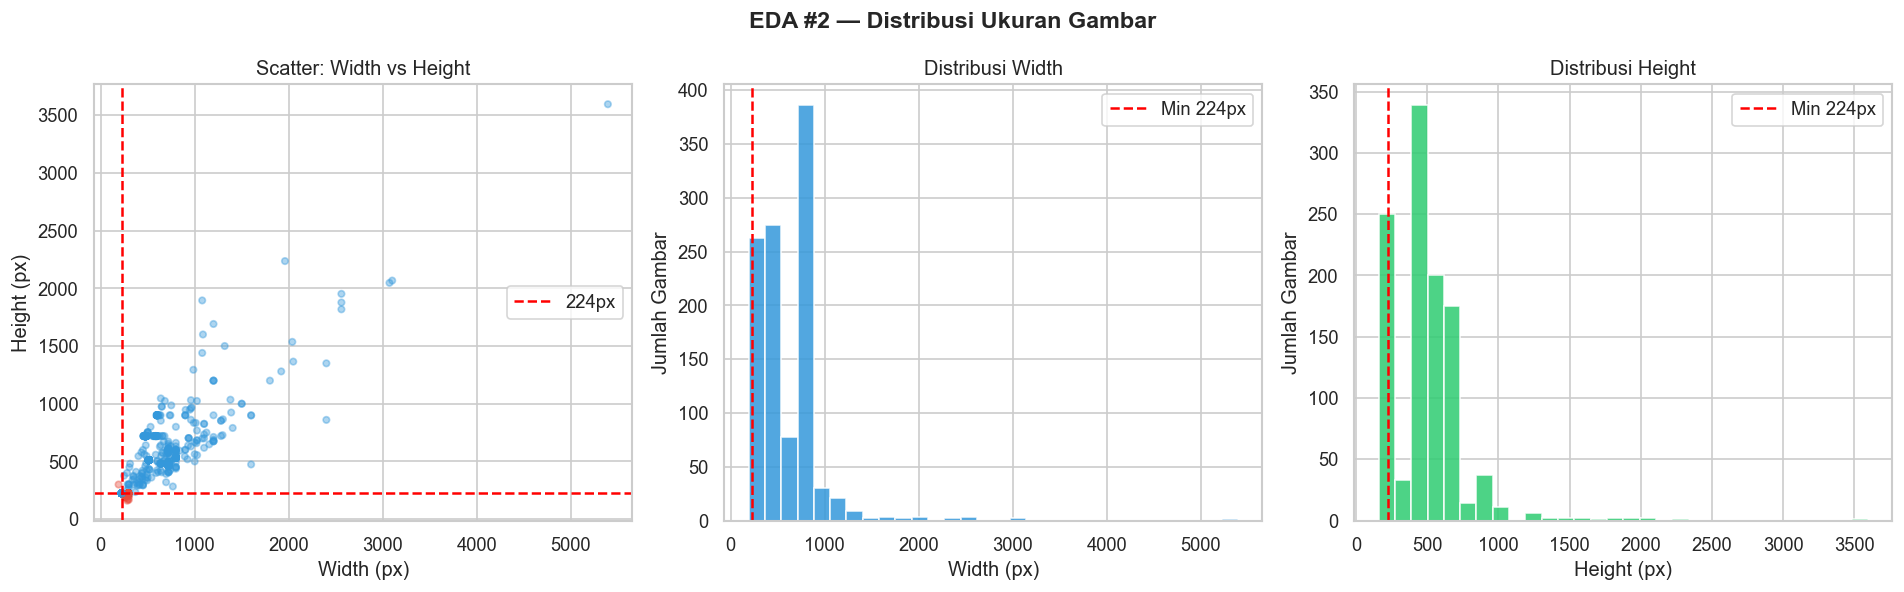

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('EDA #2 — Distribusi Ukuran Gambar', fontsize=14, fontweight='bold')

# Scatter width vs height
c_sc = ['#e74c3c' if (w < MIN_SIZE or h < MIN_SIZE) else '#3498db'
        for w, h in zip(images_df['width'], images_df['height'])]
axes[0].scatter(images_df['width'], images_df['height'], c=c_sc, alpha=0.4, s=15)
axes[0].axvline(MIN_SIZE, color='red', linestyle='--', label=f'{MIN_SIZE}px')
axes[0].axhline(MIN_SIZE, color='red', linestyle='--')
axes[0].set_xlabel('Width (px)')
axes[0].set_ylabel('Height (px)')
axes[0].set_title('Scatter: Width vs Height')
axes[0].legend()

# Histogram width
axes[1].hist(images_df['width'], bins=30, color='#3498db', edgecolor='white', alpha=0.85)
axes[1].axvline(MIN_SIZE, color='red', linestyle='--', label=f'Min {MIN_SIZE}px')
axes[1].set_xlabel('Width (px)')
axes[1].set_ylabel('Jumlah Gambar')
axes[1].set_title('Distribusi Width')
axes[1].legend()

# Histogram height
axes[2].hist(images_df['height'], bins=30, color='#2ecc71', edgecolor='white', alpha=0.85)
axes[2].axvline(MIN_SIZE, color='red', linestyle='--', label=f'Min {MIN_SIZE}px')
axes[2].set_xlabel('Height (px)')
axes[2].set_ylabel('Jumlah Gambar')
axes[2].set_title('Distribusi Height')
axes[2].legend()

plt.tight_layout()
plt.savefig('02_ukuran_gambar.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:**
- Ditemukan lebih dari satu variasi ukuran gambar dalam dataset — dataset bersifat heterogen dalam hal resolusi.
- Sebagian besar gambar berukuran di atas 224×224 px, namun distribusi yang tidak seragam tetap **mengharuskan proses resize** sebelum training.
- **Rekomendasi preprocessing:** Resize semua gambar ke **640×640** (untuk YOLOv8) atau **512×512** (untuk EfficientDet) dengan padding agar aspek rasio asli terjaga (*letterboxing*).

---

### Eksplorasi Sampel Visual per Kelas

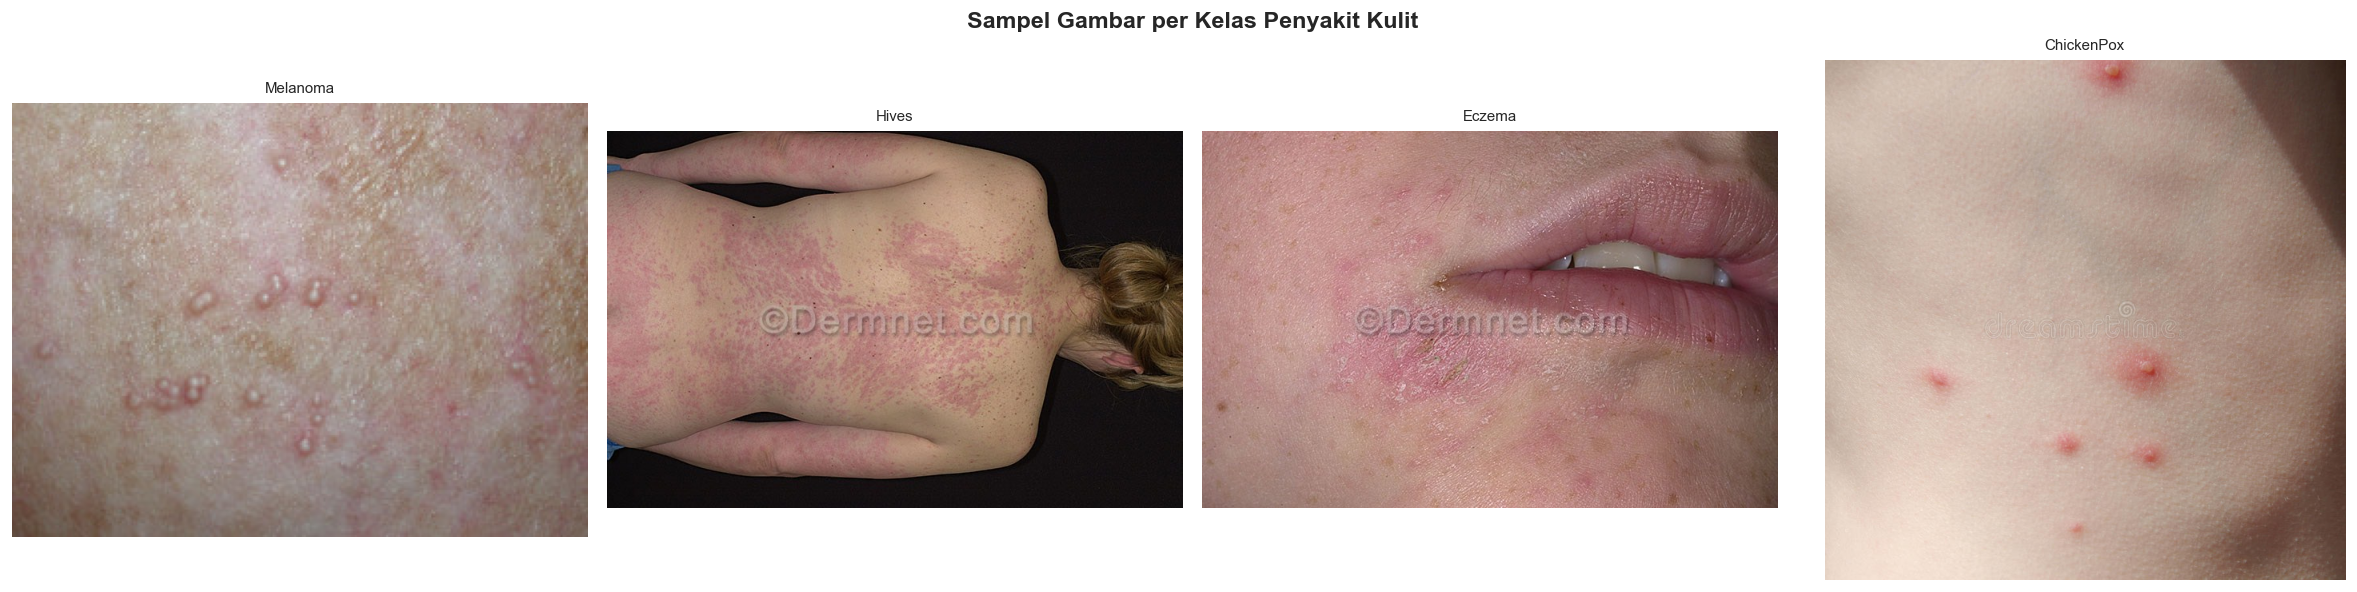

In [23]:
unique_labels       = df['label'].unique()
num_classes_to_show = min(10, len(unique_labels))

fig, axes = plt.subplots(1, num_classes_to_show, figsize=(20, 5))
fig.suptitle('Sampel Gambar per Kelas Penyakit Kulit', fontsize=14, fontweight='bold')

for i, label in enumerate(unique_labels[:num_classes_to_show]):
    sample = df[df['label'] == label].sample(1).iloc[0]
    img = Image.open(sample['file_path'])
    axes[i].imshow(img)
    short_label = label[:18] + '…' if len(label) > 18 else label
    axes[i].set_title(short_label, fontsize=9)
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('03_sampel_per_kelas.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:**
- Karakteristik visual gambar sangat bervariasi antar kelas: variasi latar belakang, pencahayaan, dan tingkat zoom berbeda di setiap sampel.
- Variasi warna kulit (*skin tone*) pasien juga beragam, yang menjadi tantangan sekaligus kekayaan dataset untuk generalisasi model.

---

## Conclusion

- **Conclusion Pertanyaan 1 (Distribusi Kelas):**
  Distribusi anotasi per kelas menunjukkan apakah dataset seimbang atau tidak. Jika rasio max/min melebihi 3:1, maka terdapat *class imbalance* yang dapat membuat model bias terhadap kelas mayoritas dan kurang akurat pada kelas minoritas.

  **Rekomendasi:** Terapkan **Data Augmentation** pada kelas minoritas dan/atau gunakan `class_weight='balanced'` saat training. Evaluasi per kelas (precision, recall, F1) wajib dilakukan agar performa model adil untuk semua kelas.

- **Conclusion Pertanyaan 2 (Konsistensi Ukuran Gambar):**
  Dataset memiliki variasi ukuran gambar yang heterogen — tidak ada satu ukuran pun yang seragam. Kondisi ini merupakan konsekuensi dari pengumpulan gambar dari berbagai sumber klinis. Seluruh gambar **wajib di-resize** ke dimensi seragam sebelum dimasukkan ke pipeline training agar model mendapatkan input yang konsisten.

  **Rekomendasi:** Gunakan resize ke **640×640** dengan teknik *letterboxing* (padding) untuk menjaga aspek rasio asli gambar — standar pada YOLOv8 dan model deteksi modern. Dataset bersih ini siap diteruskan kepada **AI Engineer**.

### Menyimpan Data ke File

In [24]:
import os, json
os.makedirs('output', exist_ok=True)

# ── Data bersih ───────────────────────────────────────────────────────────────
clean_images = images_df[~images_df['id'].isin(no_ann_ids)].reset_index(drop=True)
clean_ann    = annotations_df.drop(columns=['bbox_size_category'], errors='ignore')
valid_img_ids_final = set(clean_images['id'])
clean_ann = clean_ann[clean_ann['image_id'].isin(valid_img_ids_final)].reset_index(drop=True)

# ── 1. CSV ────────────────────────────────────────────────────────────────────
clean_images.drop(columns=['bbox', 'segmentation'], errors='ignore').to_csv(
    'output/images_cleaned.csv', index=False
)
clean_ann.drop(columns=['bbox', 'segmentation'], errors='ignore').to_csv(
    'output/annotations_cleaned.csv', index=False
)
class_stats.to_csv('output/class_distribution.csv', index=False)

# ── 2. COCO JSON (_annotations.coco.json) ────────────────────────────────────
# Rekonstruksi field bbox dari kolom terpisah (format COCO: [x, y, w, h])
coco_annotations = []
for _, row in clean_ann.iterrows():
    coco_annotations.append({
        'id'          : int(row['id']),
        'image_id'    : int(row['image_id']),
        'category_id' : int(row['category_id']),
        'bbox'        : [float(row['bbox_x']), float(row['bbox_y']),
                         float(row['bbox_w']), float(row['bbox_h'])],
        'area'        : float(row['bbox_area']),
        'segmentation': [],
        'iscrowd'     : 0,
    })

coco_images = [
    {
        'id'       : int(r['id']),
        'file_name': r['file_name'],
        'width'    : int(r['width']),
        'height'   : int(r['height']),
    }
    for _, r in clean_images.iterrows()
]

coco_categories = [
    {
        'id'           : int(r['id']),
        'name'         : r['name'],
        'supercategory': r.get('supercategory', 'skin_disease'),
    }
    for _, r in categories_df.iterrows()
]

coco_output = {
    'info': coco.get('info', {
        'description' : 'Skin Disease Dataset — Cleaned',
        'version'     : '1.0',
        'date_created': pd.Timestamp.now().strftime('%Y-%m-%d'),
    }),
    'licenses'   : coco.get('licenses', []),
    'images'     : coco_images,
    'annotations': coco_annotations,
    'categories' : coco_categories,
}

with open('output/_annotations.coco.json', 'w', encoding='utf-8') as f:
    json.dump(coco_output, f, ensure_ascii=False, indent=2)

# ── Ringkasan ─────────────────────────────────────────────────────────────────
print('✅ File berhasil disimpan:')
print(f'   output/images_cleaned.csv       — metadata gambar bersih  ({len(clean_images)} gambar)')
print(f'   output/annotations_cleaned.csv  — anotasi bersih          ({len(clean_ann)} anotasi)')
print(f'   output/class_distribution.csv   — distribusi kelas        ({len(class_stats)} kelas)')
print(f'   output/_annotations.coco.json   — format COCO lengkap     ({len(coco_images)} gambar, {len(coco_annotations)} anotasi)')
print()
print(f'   Total gambar final  : {len(clean_images)}')
print(f'   Total anotasi final : {len(clean_ann)}')

✅ File berhasil disimpan:
   output/images_cleaned.csv       — metadata gambar bersih  (1080 gambar)
   output/annotations_cleaned.csv  — anotasi bersih          (1474 anotasi)
   output/class_distribution.csv   — distribusi kelas        (4 kelas)
   output/_annotations.coco.json   — format COCO lengkap     (1080 gambar, 1474 anotasi)

   Total gambar final  : 1080
   Total anotasi final : 1474
